In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, LongType, DoubleType, FloatType
from pyspark.sql.functions import col, count, length,countDistinct, min as spark_min, max as spark_max,avg, stddev, approx_count_distinct

spark = SparkSession.builder \
    .appName("musicbrainz") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.executor.instances", "1") \
    .getOrCreate()

In [3]:
MBDUMP = "/expanse/lustre/projects/uci157/siribe/musicbrainz_json/mbdump"

In [4]:
artist_schema = StructType([
    StructField("id",               IntegerType(),   True),
    StructField("gid",              StringType(),    True),
    StructField("name",             StringType(),    True),
    StructField("sort_name",        StringType(),    True),
    StructField("begin_date_year",  IntegerType(),   True),
    StructField("begin_date_month", IntegerType(),   True),
    StructField("begin_date_day",   IntegerType(),   True),
    StructField("end_date_year",    IntegerType(),   True),
    StructField("end_date_month",   IntegerType(),   True),
    StructField("end_date_day",     IntegerType(),   True),
    StructField("type",             IntegerType(),   True),
    StructField("area",             IntegerType(),   True),
    StructField("gender",           IntegerType(),   True),
    StructField("comment",          StringType(),    True),
    StructField("edits_pending",    IntegerType(),   True),
    StructField("last_updated",     StringType(),    True),
    StructField("ended",            StringType(),    True),
    StructField("begin_area",       IntegerType(),   True),
    StructField("end_area",         IntegerType(),   True),
])
instrument_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
label_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("sort_name",     StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("area",          IntegerType(), True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
    StructField("ended",         StringType(),  True),
])
genre_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
area_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
tag_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("ref_count",     IntegerType(), True),
])
gender_schema = StructType([
    StructField("id",   IntegerType(), True),
    StructField("name", StringType(),  True),
])
release_group_schema = StructType([
    StructField("id",            IntegerType(), True),
    StructField("gid",           StringType(),  True),
    StructField("name",          StringType(),  True),
    StructField("type",          IntegerType(), True),
    StructField("artist_credit", IntegerType(), True),
    StructField("comment",       StringType(),  True),
    StructField("edits_pending", IntegerType(), True),
    StructField("last_updated",  StringType(),  True),
])
l_artist_label_schema = StructType([
    StructField("id",        IntegerType(), True),
    StructField("link",      IntegerType(), True),
    StructField("entity0",   IntegerType(), True),  # artist
    StructField("entity1",   IntegerType(), True),  # label
])
l_artist_release_group_schema = StructType([
    StructField("id",        IntegerType(), True),
    StructField("link",      IntegerType(), True),
    StructField("entity0",   IntegerType(), True),  # artist
    StructField("entity1",   IntegerType(), True),  # release_group
])
label_tag_schema = StructType([
    StructField("label", IntegerType(), True),
    StructField("tag",   IntegerType(), True),
    StructField("count", IntegerType(), True),
])
l_artist_genre_schema = StructType([
    StructField("artist", IntegerType(), True),
    StructField("genre",  IntegerType(), True),
    StructField("count",  IntegerType(), True),
])
l_artist_artist_schema = StructType([
    StructField("id",      IntegerType(), True),
    StructField("link",    IntegerType(), True),
    StructField("entity0", IntegerType(), True),
    StructField("entity1", IntegerType(), True),
])
release_group_tag_schema = StructType([
    StructField("release_group", IntegerType(), True),
    StructField("tag",           IntegerType(), True),
    StructField("count",         IntegerType(), True),
])
artist_tag_schema = StructType([
    StructField("artist", IntegerType(), True),
    StructField("tag",    IntegerType(), True),
    StructField("count",  IntegerType(), True),
])
artist_credit_schema = StructType([
    StructField("id",         IntegerType(), True),
    StructField("name",       StringType(),  True),
    StructField("artist_count", IntegerType(), True),
])
artist_credit_name_schema = StructType([
    StructField("artist_credit", IntegerType(), True),
    StructField("position",      IntegerType(), True),
    StructField("artist",        IntegerType(), True),
    StructField("name",          StringType(),  True),
    StructField("join_phrase",   StringType(),  True),
])
l_artist_instrument_schema = StructType([
    StructField("id",      IntegerType(), True),
    StructField("link",    IntegerType(), True),
    StructField("entity0", IntegerType(), True),  # artist
    StructField("entity1", IntegerType(), True),  # instrument
])

In [ ]:
schemas = {
    "artist": artist_schema,
    "instrument": instrument_schema,
    "label": label_schema,
    "genre": genre_schema,
    "area": area_schema,
    "tag": tag_schema,
    "gender": gender_schema,
    "release_group": release_group_schema,
    "l_artist_label": l_artist_label_schema,
    "l_artist_release_group": l_artist_release_group_schema,
    "label_tag": label_tag_schema,
    "l_artist_genre": l_artist_genre_schema,
    "l_artist_artist": l_artist_artist_schema,
    "release_group_tag": release_group_tag_schema,
    "artist_tag": artist_tag_schema,
    "artist_credit": artist_credit_schema,
    "artist_credit_name": artist_credit_name_schema,
    "l_artist_instrument": l_artist_instrument_schema,
}

dfs = {}
profile_rows = []

for table_name, schema in schemas.items():
    df = (
        spark.read
        .option("sep", "\t")
        .option("nullValue", r"\N")
        .option("header", "false")
        .option("quote", "")
        .option("escape", "")
        .schema(schema)
        .csv(f"{MBDUMP}/{table_name}")
    )

    dfs[table_name] = df

In [20]:
print(dfs.keys())

dict_keys(['artist', 'instrument', 'label', 'genre', 'area', 'tag', 'gender', 'release_group', 'l_artist_label', 'l_artist_release_group', 'label_tag', 'l_artist_genre', 'l_artist_artist', 'release_group_tag', 'artist_tag', 'artist_credit', 'artist_credit_name', 'l_artist_instrument'])


Pie Chart For Artist Gender

In [9]:
artistdf = dfs["artist"]
genderdf = dfs["gender"]

In [10]:
from pyspark.sql.functions import count

artists_by_gender = artistdf.join(
    genderdf,
    artistdf.gender == genderdf.id
).groupBy(
    genderdf.name.alias("gender")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
)
artists_by_gender.show()

+--------------+------+
|        gender| count|
+--------------+------+
|          Male|932192|
|        Female|280203|
|Not applicable|  2443|
|    Non-binary|  2237|
|         Other|  1787|
+--------------+------+



In [11]:
artist_gender = artists_by_gender.toPandas()

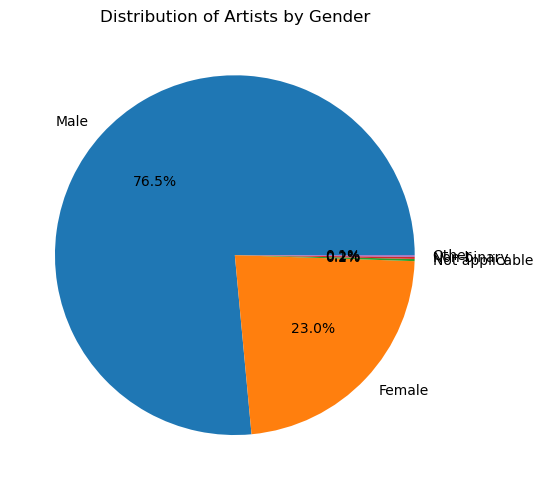

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.pie(artist_gender["count"], labels = artist_gender["gender"], autopct ='%1.1f%%')
plt.title("Distribution of Artists by Gender")
plt.tight_layout()
plt.show()

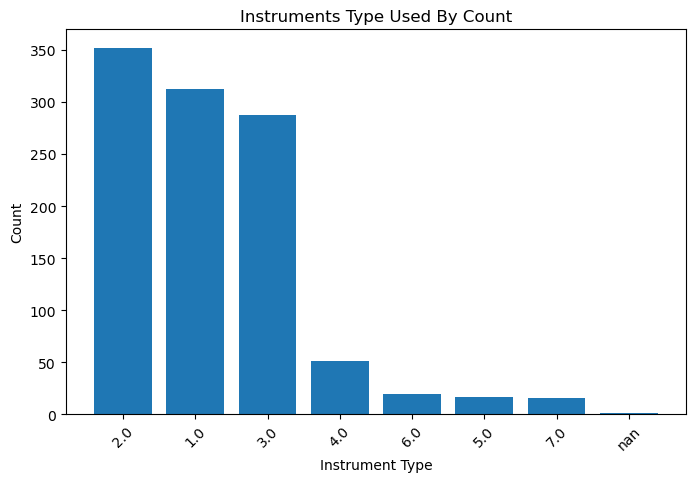

In [55]:
from pyspark.sql.functions import count

instrument_counts = dfs["instrument"].groupBy("type") \
    .agg(count("*").alias("count")) \
    .orderBy("count", ascending=False) \

instrument_dist = instrument_counts.toPandas()

plt.figure(figsize=(8,5))
plt.bar(instrument_dist["type"].astype(str), instrument_dist["count"])
plt.title("Instruments Type Used By Count")
plt.xlabel("Instrument Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Bar Chart For Release Group Tag

In [22]:
release_tags = dfs["release_group_tag"].join(
    dfs["tag"],
    dfs["release_group_tag"].tag == dfs["tag"].id
).groupBy(
    dfs["tag"].name.alias("tag")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
).limit(15)

release_tags.show()

+----------------+------+
|             tag| count|
+----------------+------+
|      electronic|507667|
|            rock|484442|
|             pop|260276|
|            jazz|128848|
|    experimental|123529|
|         ambient| 99194|
|         hip hop| 98943|
|            punk| 73250|
|       classical| 68145|
|        pop rock| 65195|
|      indie rock| 65022|
|          techno| 63127|
|           house| 60638|
|alternative rock| 59830|
|       downtempo| 50924|
+----------------+------+



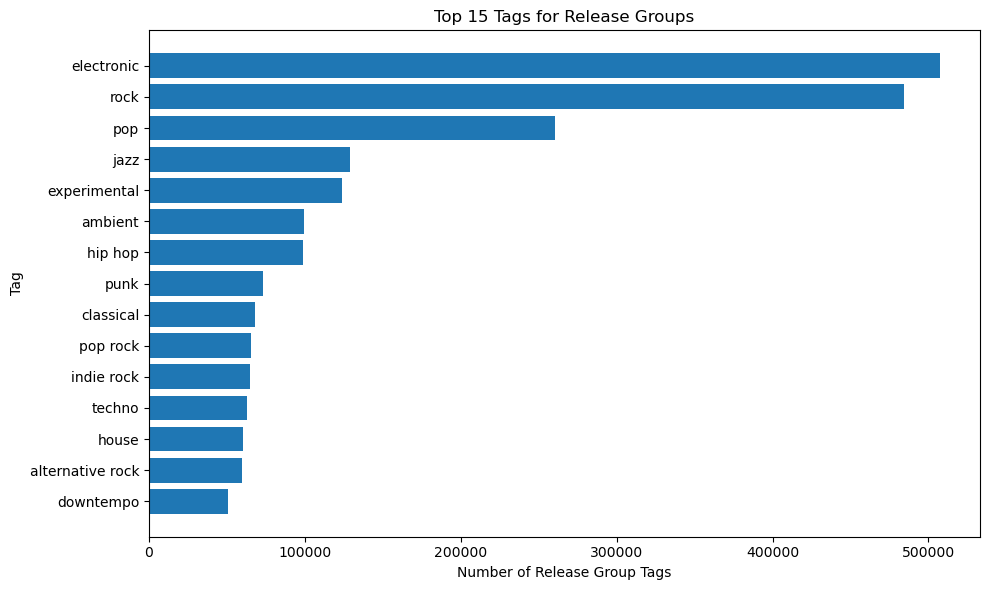

In [23]:
release_tags_pd = release_tags.toPandas()

plt.figure(figsize=(10,6))
plt.barh(release_tags_pd["tag"], release_tags_pd["count"])
plt.title("Top 15 Tags for Release Groups")
plt.xlabel("Number of Release Group Tags")
plt.ylabel("Tag")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Bar Chart For Artist Label Count

In [24]:
label_artist_counts = dfs["l_artist_label"].join(
    dfs["label"],
    dfs["l_artist_label"].entity1 == dfs["label"].id
).groupBy(
    dfs["label"].name.alias("label")
).agg(
    count("*").alias("artist_links")
).orderBy(
    "artist_links", ascending=False
).limit(15)

label_artist_counts.show()

+--------------------+------------+
|               label|artist_links|
+--------------------+------------+
|       Audio Network|         514|
|Fruits de Mer Rec...|         331|
|Firefly Entertain...|         212|
|Beverina Productions|         155|
| Candlelight Records|         139|
|              Lantis|         108|
|          Geertruida|         100|
|Prophecy Productions|          94|
|     Pinkamena Party|          87|
|    SM Entertainment|          83|
|      Season of Mist|          82|
|     Sonar Kollektiv|          81|
|    Doghouse Records|          81|
|     Independent Co.|          80|
|                FCMG|          78|
+--------------------+------------+



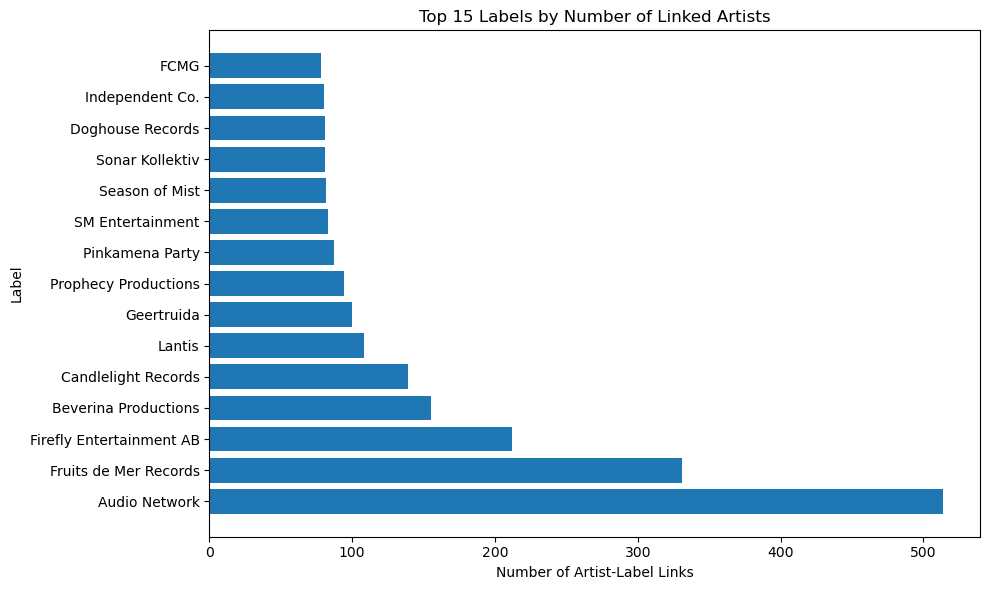

In [30]:
label_artist_pd = label_artist_counts.toPandas()

plt.figure(figsize=(10,6))
plt.barh(label_artist_pd["label"], label_artist_pd["artist_links"])
plt.title("Top 15 Labels by Number of Linked Artists")
plt.xlabel("Number of Artist-Label Links")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

Histogram For Artist Credit

In [43]:
credit_sizes = dfs["artist_credit_name"].groupBy("artist_credit") \
    .agg(count("*").alias("num_artists"))
credit_sizes.show(5)

+-------------+-----------+
|artist_credit|num_artists|
+-------------+-----------+
|       198909|          1|
|        99239|          1|
|       205306|          1|
|       268819|          1|
|        99168|          1|
+-------------+-----------+
only showing top 5 rows



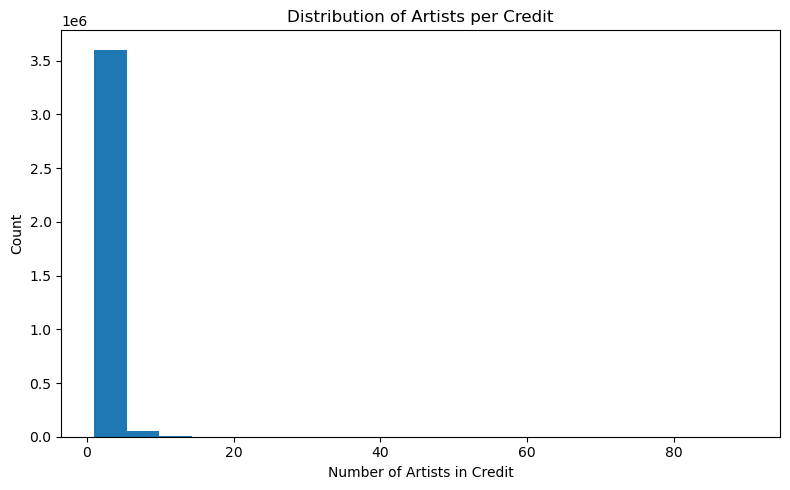

In [45]:
cred = credit_sizes.toPandas()

plt.figure(figsize=(8,5))

plt.hist(cred["num_artists"], bins=20)

plt.title("Distribution of Artists per Credit")
plt.xlabel("Number of Artists in Credit")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Bar Plot For Artist By Area

In [46]:
artist_areas = dfs["artist"].join(
    dfs["area"],
    dfs["artist"].area == dfs["area"].id
).groupBy(
    dfs["area"].name.alias("area")
).agg(
    count("*").alias("count")
).orderBy(
    "count", ascending=False
).limit(15)

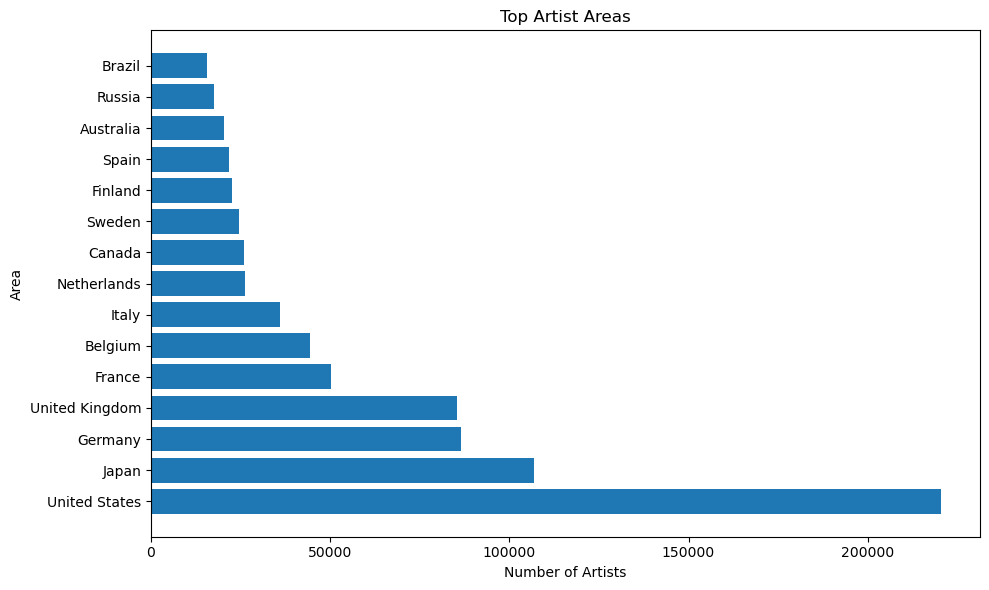

In [47]:
art_area = artist_areas.toPandas()

plt.figure(figsize=(10,6))
plt.barh(art_area["area"], art_area["count"])

plt.title("Top Artist Areas")
plt.xlabel("Number of Artists")
plt.ylabel("Area")
plt.tight_layout()
plt.show()